# Importing Libraries and functions

In [1]:
import pandas as pd
import numpy as np

# To save and load our models
import pickle

# To plot 
import matplotlib.pyplot as plt
import seaborn  as sns

# To training the model
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.ensemble        import RandomForestClassifier
from xgboost import XGBClassifier

# Explainability
import shap
from sklearn.inspection import permutation_importance

# Fairlearn 
from fairlearn.reductions import EqualizedOdds, ExponentiatedGradient
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import demographic_parity_difference, demographic_parity_ratio
from fairlearn.metrics import equalized_odds_difference,  equalized_odds_ratio
from fairlearn.metrics import selection_rate, true_negative_rate, true_positive_rate, false_positive_rate, false_negative_rate
from fairlearn.metrics import MetricFrame

# Personalized functions
from functions import compute_metrics, fpr, fnr, tmo

# Importing the data

In [2]:
df_trainval = pd.read_csv('CSV_TRAIN.csv', sep = ";")
df_test     = pd.read_csv('CSV_TEST.csv',  sep = ";")

df_trainval['TARGET'] = 1 - df_trainval["DEFAULT"]
df_test['TARGET']     = 1 - df_test["DEFAULT"]

# Analyzing correlations

The objective of this notebook is to create a new model eliminating the variables that correlate with our protected features. The idea behind this is Fairness as unawareness: if the model is not able to tell from the data if someone belongs or not to a protected group, it can not discriminate him/her for belonging to that class.

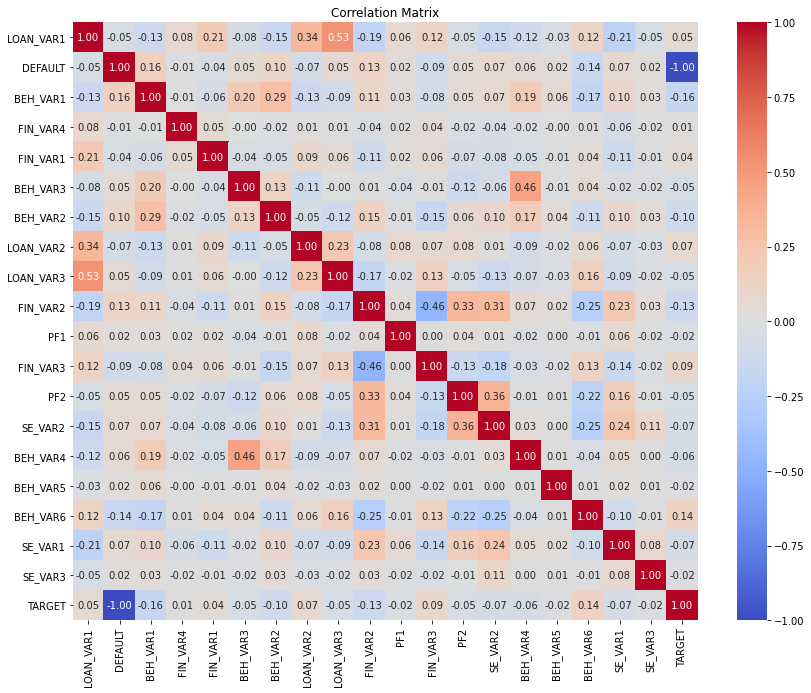

In [3]:
corr = df_trainval.corr()

# Crear heatmap
plt.figure(figsize=(14, 11))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Matrix')
plt.show()

In the correlation matrix we can observe that there are not any variables with Protected feature 1, but there are some that have some correlation with the Protected Feature 2, which is the Protected feature the base model presented bias against. We will drop all the features that have more than 0.1 correlation with the Protected feature 2. Those are: SE_VAR1, SE_VAR3, BEH_VAR6, FIN_VAR2, FIN_VAR3, BEH_VAR3, BEH_VAR2 

In [4]:
columns_to_be_dropped = ["SE_VAR1", "SE_VAR3", "BEH_VAR6", "FIN_VAR2", "FIN_VAR3", "BEH_VAR3", "BEH_VAR2"]

df_trainval_nonulls = df_trainval.dropna().drop(columns_to_be_dropped, axis = 1).reset_index(drop=True)
df_test_nonulls     = df_test.dropna().drop(columns_to_be_dropped, axis = 1).reset_index(drop=True)

In [5]:
print(f"After dropping {df_trainval.shape[0] - df_trainval_nonulls.shape[0]} instances with some nulls, the training set has {df_trainval_nonulls.shape[0]} observations")
print(f"After dropping {df_test.shape[0]     - df_test_nonulls.shape[0]} instances with some nulls, the test set has {df_test_nonulls.shape[0]} observations")

After dropping 25 instances with some nulls, the training set has 20029 observations
After dropping 10 instances with some nulls, the test set has 5726 observations


In [6]:
X_trainval   = df_trainval_nonulls.drop(['DEFAULT','TARGET'], axis = 1)
Y_trainval   = df_trainval_nonulls['TARGET']

X_train, X_val, Y_train, Y_val = train_test_split(X_trainval, Y_trainval, test_size = 0.25, random_state = 1)

X_test   = df_test_nonulls.drop(['DEFAULT','TARGET'], axis = 1)
Y_test   = df_test_nonulls['TARGET']


PF1_train = X_train['PF1']
PF2_train = X_train['PF2']

PF1_val   = X_val['PF1']
PF2_val   = X_val['PF2']

PF1_test  = X_test['PF1']
PF2_test = X_test['PF2']

X_train = X_train.drop(['PF1', 'PF2'], axis = 1)
X_val   = X_val.drop(['PF1', 'PF2'], axis = 1)
X_test  = X_test.drop(['PF1', 'PF2'], axis = 1)

In [7]:
print(f" The dataset we will use for training   has {X_train.shape[0]} observations and {X_train.shape[1]} features.")
print(f" The dataset we will use for validation has {X_val.shape[0]} observations and {X_train.shape[1]} features.")
print(f" The dataset we will use for test       has {X_test.shape[0]} observations and {X_test.shape[1]} features.")

 The dataset we will use for training   has 15021 observations and 9 features.
 The dataset we will use for validation has 5008 observations and 9 features.
 The dataset we will use for test       has 5726 observations and 9 features.


# Fine tunning

As with our base model, we will use XGBoost as our algorithm to create the score. We will use GridSearch to search the optimal hyperparameters.

In [8]:
param_grid = {
    'max_depth': [2, 4],
    'learning_rate': [0.01, 0.025, 0.05],
    'n_estimators': [500, 1000],
    'gamma': [10, 25],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.75],
    'min_child_weight': [8, 32],
    'early_stopping_rounds': [50]}

In [9]:
xgb = XGBClassifier(random_state=1)

grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=4, scoring='roc_auc', n_jobs=2, verbose=1, return_train_score=True)

# Calling grid_search on our data
grid_search.fit(X_train, Y_train)

# Save the results
cv_results = grid_search.cv_results_

# We create a df with the AUC obtained in train and test for different hyperparameters. 
results_df = pd.DataFrame({'params': cv_results['params'],
                           'mean_train_gini': 2*cv_results['mean_train_score']-1,
                           'mean_test_gini': 2*cv_results['mean_test_score']-1,
                           'gini_diff': (2*cv_results['mean_train_score'] -1) - (2*cv_results['mean_test_score']-1)})

Fitting 4 folds for each of 96 candidates, totalling 384 fits


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:  1.8min
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:  7.8min
[Parallel(n_jobs=2)]: Done 384 out of 384 | elapsed: 15.3min finished


From those who do not present significant overfitting, we will choose the one with a higher AUC in the test part of the cross-validation.

In [10]:
results_df_filter = results_df.sort_values('mean_test_gini', ascending=False)
results_df_filter = results_df_filter[results_df_filter['gini_diff']<0.03]
results_df_filter.head()

,params,mean_train_gini,mean_test_gini,gini_diff
94,"{'colsample_bytree': 0.75, 'early_stopping_rou...",0.444960,0.415157,0.029804
92,"{'colsample_bytree': 0.75, 'early_stopping_rou...",0.443159,0.413745,0.029414
82,"{'colsample_bytree': 0.75, 'early_stopping_rou...",0.439971,0.413490,0.026481
86,"{'colsample_bytree': 0.75, 'early_stopping_rou...",0.439441,0.413101,0.026340
78,"{'colsample_bytree': 0.75, 'early_stopping_rou...",0.441154,0.412173,0.028981


In [11]:
best_hyperparams = results_df_filter.sort_values('mean_test_gini', ascending=False)\
                    [results_df_filter['gini_diff']<0.03].iloc[0, 0]
print(best_hyperparams)

{'colsample_bytree': 0.75, 'early_stopping_rounds': 50, 'gamma': 25, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 32, 'n_estimators': 1000, 'subsample': 0.8}


Boolean Series key will be reindexed to match DataFrame index.


Once we have the best hyperparameters, we train the model using those and we save it.

In [12]:
best_xgb = XGBClassifier(**best_hyperparams, random_state=1, n_jobs=2)
best_xgb.fit(X_train, Y_train)


XGBClassifier(colsample_bytree=0.75, early_stopping_rounds=50, gamma=25,
              learning_rate=0.05, max_depth=4, min_child_weight=32,
              n_estimators=1000, n_jobs=2, random_state=1, subsample=0.8)

# Saving the model

In [13]:
# We save the hyperparameters for the model in a csv
xgb_unaware_hparams = pd.DataFrame([best_hyperparams])
xgb_unaware_hparams.to_csv("xgb_unaware_hparams.csv", index=False)

pickle.dump(best_xgb, open('modelXGB_unaware.cls', 'wb'))

# Evaluating model performance

In [14]:
unaware_xgb = pickle.load(open('./modelXGB_unaware.cls', "rb"))

Let us take a look at the performance of the model in different datasets. It is normal for the model to loose a bit of performance, but we expect our model to hold significant ordenation capacity in datasets it has not seen. Otherwise, it would either mean that the model has overfitted the training data or that validation and test datasets differ in an important way from the training data, neither of those options would be good. 

In [15]:
prob_train = unaware_xgb.predict_proba(X_train)[:, 1]
prob_val   = unaware_xgb.predict_proba(X_val)[:, 1]
prob_test  = unaware_xgb.predict_proba(X_test)[:, 1]

auc_score_train  = roc_auc_score(Y_train, prob_train)
gini_score_train = 2*auc_score_train-1

auc_score_val = roc_auc_score(Y_val, prob_val)
gini_score_val = 2*auc_score_val-1

auc_score_test  = roc_auc_score(Y_test, prob_test)
gini_score_test = 2*auc_score_test-1

print(f"El ROC-AUC del modelo en train es {auc_score_train:.4f}")
print(f"El GINI del modelo  en train es {gini_score_train:.4f}")

print(f"El ROC-AUC del modelo en validación es {auc_score_val:.4f}")
print(f"El GINI del modelo  en validación es {gini_score_val:.4f}")

print(f"El ROC-AUC del modelo en test es {auc_score_test:.4f}")
print(f"El GINI del modelo  en test es {gini_score_test:.4f}")

El ROC-AUC del modelo en train es 0.7243
El GINI del modelo  en train es 0.4485
El ROC-AUC del modelo en validación es 0.7102
El GINI del modelo  en validación es 0.4203
El ROC-AUC del modelo en test es 0.6972
El GINI del modelo  en test es 0.3944


We can already see that this models has lost a lot of performance. This is to be expected, as we dropped some of the more important features of the base model.

# Explainability

In order to understand better how this unaware model works let's take a look at the feature importance, the permutation feature importance and shap values of this model.

In [16]:
importancias = unaware_xgb.feature_importances_
df_importancia = pd.DataFrame({'Variable': X_train.columns, 'Importancia': importancias}).sort_values(by = 'Importancia', ascending = False)

In [17]:
print(df_importancia)

    Variable  Importancia
1   BEH_VAR1     0.196218
3   FIN_VAR1     0.145210
5  LOAN_VAR3     0.106306
6    SE_VAR2     0.105099
8   BEH_VAR5     0.104442
7   BEH_VAR4     0.101582
4  LOAN_VAR2     0.082987
2   FIN_VAR4     0.080147
0  LOAN_VAR1     0.078008


In [18]:
permutation_importance = permutation_importance(unaware_xgb, X_train, Y_train, scoring='roc_auc', n_repeats=5, random_state = 1)

In [19]:
importances = permutation_importance.importances_mean
feature_importance = pd.Series(importances, index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)
print(feature_importance)

BEH_VAR1     0.105625
LOAN_VAR3    0.039568
FIN_VAR1     0.032585
SE_VAR2      0.003374
LOAN_VAR1    0.003293
BEH_VAR5     0.003270
LOAN_VAR2    0.001413
BEH_VAR4     0.000310
FIN_VAR4     0.000275
dtype: float64


We could also use SHAP values, that use a game-theory approach to determine the contribution of each feature to the final prediction.

In [20]:
explainer = shap.TreeExplainer(unaware_xgb)
shap_values = explainer.shap_values(X_train)

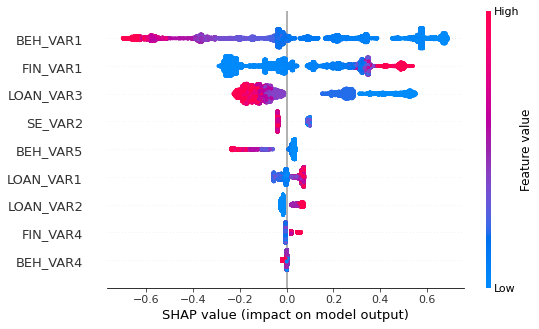

In [21]:
shap.summary_plot(shap_values, X_train)

Here, it is important to make economic sense of how each feature affects the final prediction. If the behaviour does not respond to an economic logic, we should remove the feature and retrain the model. 

If a client were to ask why a certain decision was made about his application we could use the SHAP values to get an idea of which factors the model took into account to approve or reject its application. Let us see an example.

In this case we observe that economic rational of the variable stays the same, which is to be expected. The only difference is that some variables win importance in the model to fill the void the variables we dropped left.

In [22]:
pos = 625
x_i = X_test.iloc[[pos]]
shap_values = explainer(x_i)
Y_test.iloc[[pos]]
print(prob_test[pos])

0.95644784


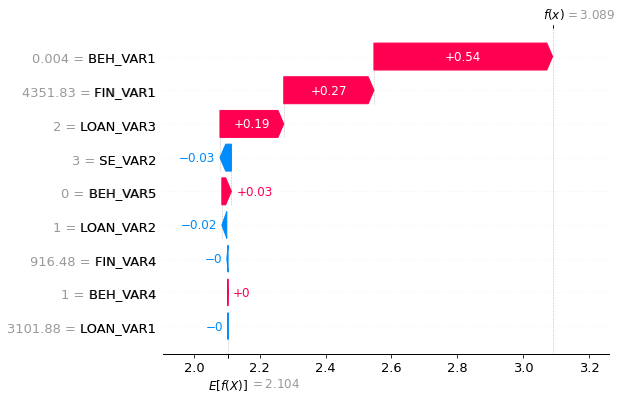

In [23]:
shap.plots.waterfall(shap_values[0])

# Deciding the optimal threshold

We use the validation set to find the optimal threshold. The criteria we will use will be the following: "From those thresholds the default rate of the approved loans do not exceed 5%, we will choose the one with higher approval rate". This matches well the balance we want to find between automating the most amount of loans while not taking excessive risk. The % of default rate tolerated will vary depending on the bank's risk appetite.

In [24]:
thresholds = np.linspace(0.7, 1, 250)

rows = []

for t in thresholds:
    resultado = compute_metrics(X_val, Y_val, unaware_xgb, t)
    rows.append(resultado)

df_metricas = pd.DataFrame(rows, columns=['Threshold', 'TMO', 'approvalRate', 'Recall', 'Precision', 'FPR', 'FNR'])

In [25]:
df_metricas_filtered = df_metricas.sort_values('approvalRate', ascending=False)
df_metricas_filtered = df_metricas_filtered[df_metricas_filtered['TMO']< 0.05]
df_metricas_filtered.head()

,Threshold,TMO,approvalRate,Recall,Precision,FPR,FNR
173,0.908434,0.048585,0.472644,0.503128,0.951415,0.216165,0.496872
174,0.909639,0.048801,0.466454,0.496425,0.951199,0.214286,0.503575
175,0.910843,0.049237,0.458267,0.487489,0.950763,0.212406,0.512511
176,0.912048,0.048889,0.449281,0.478105,0.951111,0.206767,0.521895
177,0.913253,0.048504,0.440495,0.468945,0.951496,0.201128,0.531055


In [26]:
best_threshold = df_metricas_filtered.iloc[0,0]

# Performance on the test set

In [27]:
rows_test = []
resultado = compute_metrics(X_test, Y_test, unaware_xgb, best_threshold)
rows_test.append(resultado)

df_metricas_test = pd.DataFrame(rows_test, columns=['Threshold', 'TMO', 'approvalRate', 'Recall', 'Precision', 'FPR', 'FNR'])
df_metricas_test.head()

,Threshold,TMO,approvalRate,Recall,Precision,FPR,FNR
0,0.908434,0.054054,0.484632,0.514202,0.945946,0.241546,0.485798


With the threshold we picked using the validation dataset, the bank approves automatically 48,5% of the loans, in comparison with the 56,4% it approved in the base model. This represents 51,4% of the good aplicants vs 60% in the base model.

Thus, it is clear that this model performance is much worse. Let us see if, at least, bias has been reduced.

# Fairness Metrics

To analyze possible biases, we will use the fairlearn library.

In [28]:
metrics = {
    "N": lambda y_true, y_pred: len(y_true),
    "Default_rate": tmo,
    "Accuracy": accuracy_score,
    "Precision": precision_score,
    "Recall": recall_score,
    "Selection_rate": selection_rate,
    "FPR": false_positive_rate,
    "FNR": false_negative_rate,
    "Specificity": true_negative_rate
}

mf1 = MetricFrame(
    metrics=metrics,
    y_true= Y_test,
    y_pred=(prob_test > best_threshold),
    sensitive_features= PF1_test
)

mf2 = MetricFrame(
    metrics=metrics,
    y_true= Y_test,
    y_pred=(prob_test > best_threshold),
    sensitive_features= PF2_test
)

# Check the combination of features, this is called intersectional fairness, 
# it could happen that at group level the model is fair
# but when considering the combination of protected features we might detect bias
intersectional_fairness = pd.DataFrame({"PF1": PF1_test, "PF2": PF2_test})

mf12 = MetricFrame(
    metrics=metrics,
    y_true= Y_test,
    y_pred=(prob_test > best_threshold),
    sensitive_features= intersectional_fairness
)

Fairness Metrics grouped by Protected Feature 1

In [29]:
mf1.by_group.head()

,N,Default_rate,Accuracy,Precision,Recall,Selection_rate,FPR,FNR,Specificity
PF1,,,,,,,,,
0,2522,0.0488627,0.522205,0.951137,0.496046,0.470658,0.235772,0.503954,0.764228
1,3204,0.0579345,0.555243,0.942065,0.528809,0.49563,0.245333,0.471191,0.754667


In [30]:
mf1.ratio()

N                 0.787141
Default_rate      0.843412
Accuracy          0.940497
Precision         0.990462
Recall            0.938044
Selection_rate    0.949615
FPR               0.961029
FNR               0.934988
Specificity       0.987489
dtype: object

Fairness Metrics grouped by Protected Feature 2

In [31]:
mf2.by_group.head()

,N,Default_rate,Accuracy,Precision,Recall,Selection_rate,FPR,FNR,Specificity
PF2,,,,,,,,,
0,3484,0.0549809,0.567164,0.945019,0.552339,0.527268,0.296188,0.447661,0.703812
1,2242,0.0522388,0.499554,0.947761,0.453109,0.418376,0.175,0.546891,0.825


In [32]:
mf2.ratio()

N                 0.643513
Default_rate      0.950126
Accuracy          0.880793
Precision         0.997107
Recall            0.820347
Selection_rate     0.79348
FPR               0.590842
FNR               0.818557
Specificity       0.853106
dtype: object

Fairness Metrics grouped by the intersections of both protected features

In [33]:
mf12.by_group.head()

N Default_rate  Accuracy Precision    Recall Selection_rate  \
PF1 PF2                                                                   
0   0    1609    0.0505415  0.551274  0.949458    0.5371        0.51647   
    1     913    0.0449438  0.470975  0.955056  0.421314       0.389923   
1   0    1875    0.0586481    0.5808  0.941352  0.565711       0.536533   
    1    1329     0.056701  0.519187  0.943299  0.475325       0.437923   

              FPR       FNR Specificity  
PF1 PF2                                  
0   0         0.3    0.4629         0.7  
    1    0.150943  0.578686    0.849057  
1   0    0.293532  0.434289    0.706468  
    1    0.189655  0.524675    0.810345

In [34]:
mf12.ratio()

N                 0.486933
Default_rate       0.76633
Accuracy          0.810907
Precision         0.985651
Recall            0.744751
Selection_rate    0.726746
FPR               0.503145
FNR               0.750474
Specificity       0.824444
dtype: object